# EDA Day 4

In [1]:
#  pip install adjustText

In [2]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from adjustText import adjust_text

In [3]:
sns.set_style("whitegrid")
sns.set_context('notebook')
sns.set_palette('deep')
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # for Traditional Chinese
plt.rcParams['axes.unicode_minus'] = False


In [4]:
'''# CLEAR TABLE if needed

conn = sqlite3.connect('../data ingestion mvp/taiwan_housing.db')
cursor = conn.cursor()

cursor.execute('DROP TABLE IF EXISTS transactions;')
conn.commit()

conn.close()'''

"# CLEAR TABLE if needed\n\nconn = sqlite3.connect('../data ingestion mvp/taiwan_housing.db')\ncursor = conn.cursor()\n\ncursor.execute('DROP TABLE IF EXISTS transactions;')\nconn.commit()\n\nconn.close()"

In [5]:
def load_data():
    with sqlite3.connect('../data ingestion mvp/taiwan_housing.db') as conn:
        return pd.read_sql(
            'SELECT * FROM transactions', 
            conn,
            parse_dates=['date']
        )
    
df = load_data()
df.head()

,date,address,price,area,price_per_sqm,building_type,district,transaction_type,parking_price,parking_area,main_area,net_price,net_area,computed_price_per_sqm,net_price_per_sqm,price_diff,net_price_diff,final_price_per_sqm,pricing_method
0,2026-03-01,臺北市大安區安居街８１巷１號二樓,15000000,73.46,204193,公寓(5樓含以下無電梯),大安區,房地(土地+建物),0,0.0,69.94,15000000,73.46,204193.0,204193.0,0.0,0.0,204193,original
1,2026-03-06,臺北市北投區溫泉路１４號,6150000,123.50,49798,透天厝,北投區,房地(土地+建物),0,0.0,123.50,6150000,123.50,49798.0,49798.0,0.0,0.0,49798,original
2,2026-03-02,臺北市信義區松山路４６５巷３０號三樓,3330000,12.66,263033,公寓(5樓含以下無電梯),信義區,房地(土地+建物),0,0.0,12.66,3330000,12.66,263033.0,263033.0,0.0,0.0,263033,original
3,2026-03-17,臺北市信義區松山路４６５巷２７弄２３號,31500000,81.65,385793,公寓(5樓含以下無電梯),信義區,房地(土地+建物),0,0.0,81.65,31500000,81.65,385793.0,385793.0,0.0,0.0,385793,original
4,2026-03-03,臺北市松山區南京東路四段１５８巷１號二樓,53000000,170.56,310741,公寓(5樓含以下無電梯),松山區,房地(土地+建物),0,0.0,170.56,53000000,170.56,310741.0,310741.0,0.0,0.0,310741,original


In [6]:
df.shape

(393, 19)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 393 entries, 0 to 392
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    393 non-null    datetime64[ns]
 1   address                 393 non-null    object        
 2   price                   393 non-null    int64         
 3   area                    393 non-null    float64       
 4   price_per_sqm           393 non-null    int64         
 5   building_type           393 non-null    object        
 6   district                393 non-null    object        
 7   transaction_type        393 non-null    object        
 8   parking_price           393 non-null    int64         
 9   parking_area            393 non-null    float64       
 10  main_area               393 non-null    float64       
 11  net_price               393 non-null    int64         
 12  net_area                393 non-null    float64   

In [8]:
df['transaction_type'].value_counts()

transaction_type
房地(土地+建物)       233
房地(土地+建物)+車位    160
Name: count, dtype: int64

In [9]:
df['pricing_method'].value_counts()

pricing_method
original        270
net_adjusted    123
Name: count, dtype: int64

In [10]:
df.isna().sum()

date                      0
address                   0
price                     0
area                      0
price_per_sqm             0
building_type             0
district                  0
transaction_type          0
parking_price             0
parking_area              0
main_area                 0
net_price                 0
net_area                  0
computed_price_per_sqm    0
net_price_per_sqm         0
price_diff                0
net_price_diff            0
final_price_per_sqm       0
pricing_method            0
dtype: int64

In [11]:
print(f'Start: {df['date'].min()}')
print(f'Start: {df['date'].max()}')

Start: 2020-07-25 00:00:00
Start: 2026-03-19 00:00:00


## Focus on records from 2026

In [12]:
df_mvp = df[df['date'].dt.year == 2026].copy()

In [13]:
df_mvp.shape

(222, 19)

## Variable distibutions

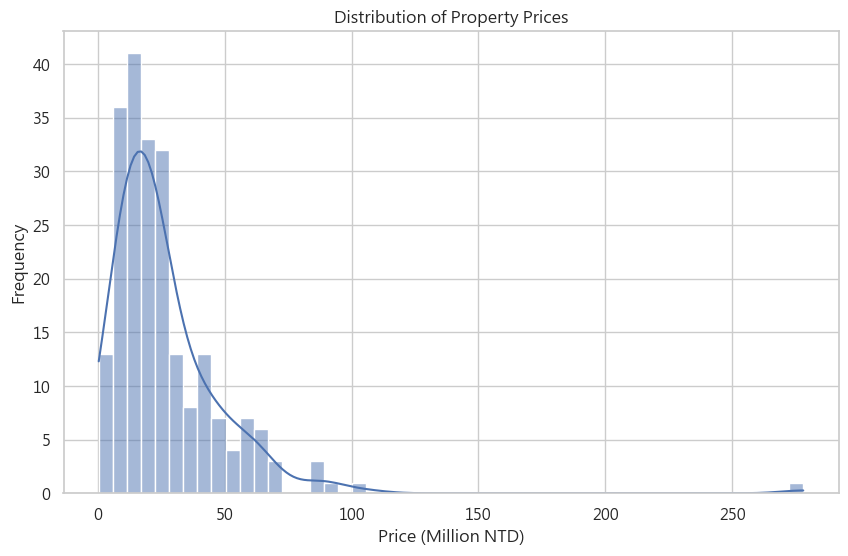

In [14]:
sns.histplot(df_mvp['price'] / 1_000_000 , bins=50, kde=True)
plt.title('Distribution of Property Prices')
plt.xlabel('Price (Million NTD)')
plt.ylabel('Frequency')

plt.show()

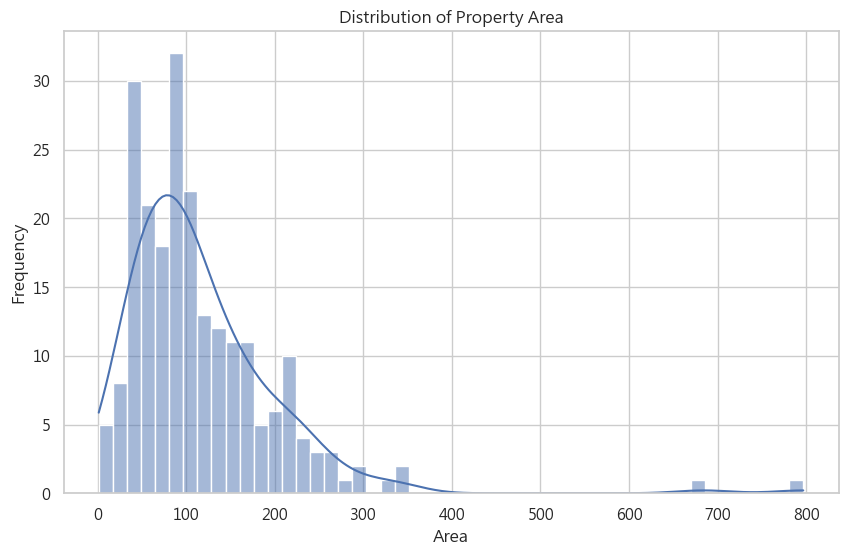

In [15]:
sns.histplot(df_mvp['area'], bins=50, kde=True)
plt.title('Distribution of Property Area')
plt.xlabel('Area')
plt.ylabel('Frequency')

plt.show()

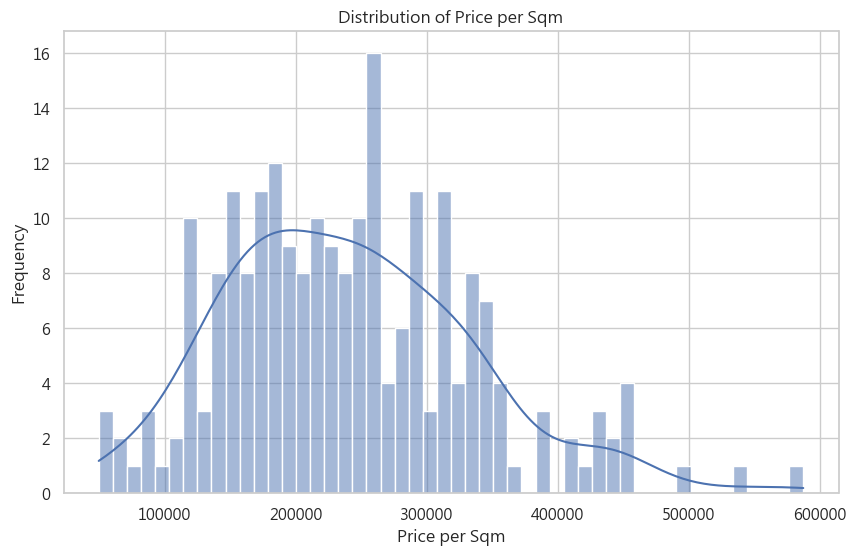

In [16]:
sns.histplot(df_mvp['final_price_per_sqm'], bins=50, kde=True)
plt.title('Distribution of Price per Sqm')
plt.xlabel('Price per Sqm')
plt.ylabel('Frequency')

plt.show()

### The distribution of the `Final Price per Sqm` now looks more normally distributed. This is most likely contributed by the effect of filtering the dataset to only **housing-related transactions only**

## Apply Log transformation

In [17]:
df_mvp['log_price'] = np.log(df['price'])
df_mvp['log_area'] = np.log(df['area'])

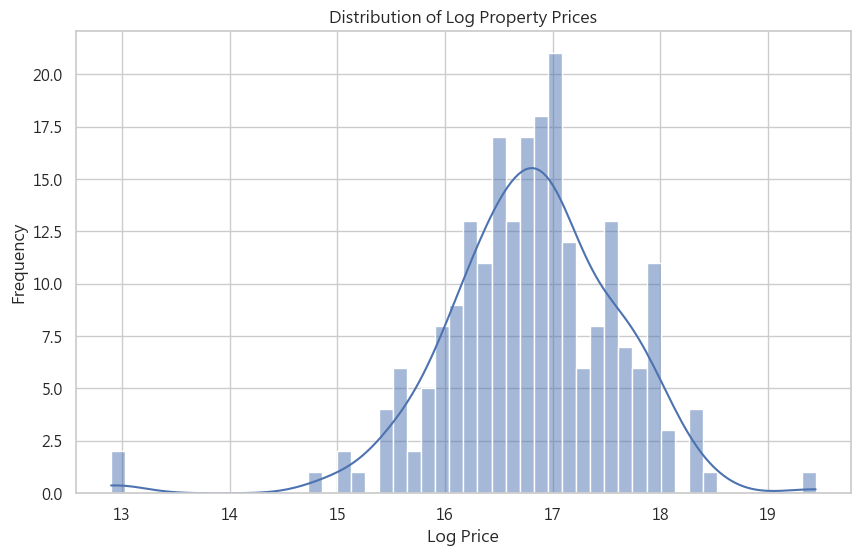

In [18]:
sns.histplot(df_mvp['log_price'], bins=50, kde=True)
plt.title('Distribution of Log Property Prices')
plt.xlabel('Log Price')
plt.ylabel('Frequency')

plt.show()

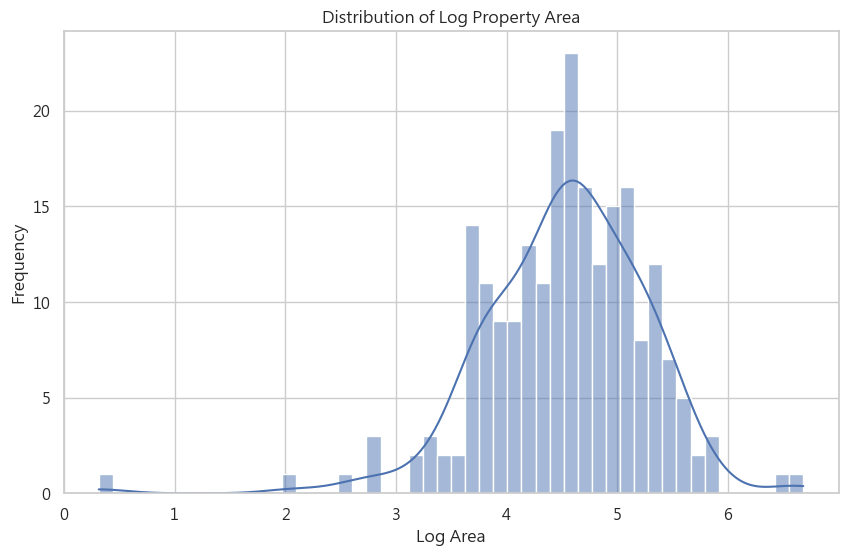

In [19]:
sns.histplot(df_mvp['log_area'], bins=50, kde=True)
plt.title('Distribution of Log Property Area')
plt.xlabel('Log Area')
plt.ylabel('Frequency')

plt.show()

In [20]:
print(f"Skew before: {df_mvp['price'].skew()}")
print(f"Skew after: {df_mvp['log_price'].skew()}")

Skew before: 5.066448156265788
Skew after: -0.8361924377274761


In [21]:
print(f"Skew before: {df_mvp['area'].skew()}")
print(f"Skew after: {df_mvp['log_area'].skew()}")

Skew before: 3.363015689551171
Skew after: -1.0004657552504084


### Applying log transformation does seems to improve interpretability on price and area

## Relationship Exploration

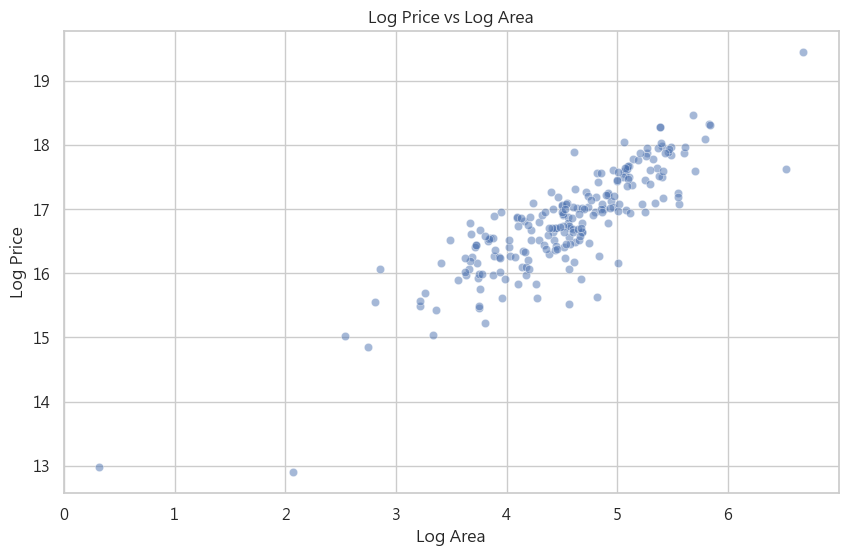

In [22]:
sns.scatterplot(
    data=df_mvp,
    x='log_area',
    y='log_price',
    alpha=0.5
)
plt.xlabel('Log Area')
plt.ylabel('Log Price')
plt.title('Log Price vs Log Area')

plt.show()

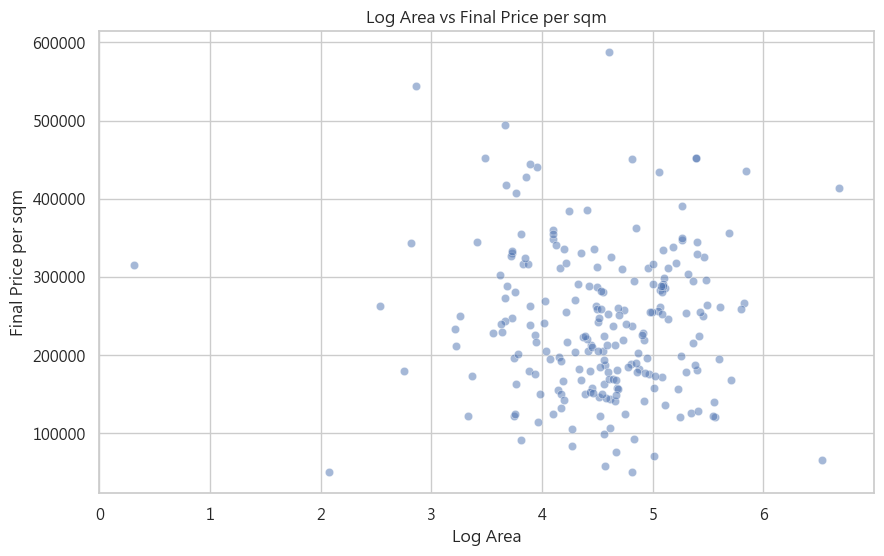

In [23]:
sns.scatterplot(
    data=df_mvp,
    x='log_area',
    y='final_price_per_sqm',
    alpha=0.5
)
plt.xlabel('Log Area')
plt.ylabel('Final Price per sqm')
plt.title('Log Area vs Final Price per sqm')

plt.show()

In [24]:
df_mvp[['log_price', 'log_area', 'final_price_per_sqm']].corr()

,log_price,log_area,final_price_per_sqm
log_price,1.000000,0.862203,0.430695
log_area,0.862203,1.000000,-0.048528
final_price_per_sqm,0.430695,-0.048528,1.000000


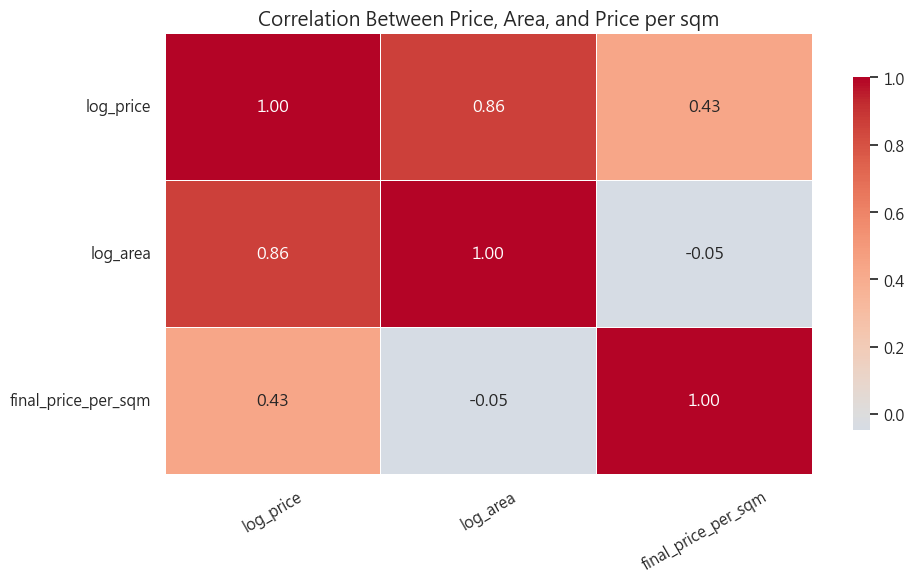

In [25]:
sns.heatmap(
    df_mvp[['log_price','log_area','final_price_per_sqm']].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink':0.8}
)
plt.title("Correlation Between Price, Area, and Price per sqm", fontsize=14)
plt.xticks(rotation=30)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Key insights
- `log_price` vs `log_area`: strong positive (bigger house -> higher total price)
- `log_area` vs `final_price_per_sqm`: very small negative (larger properties -> cheaper per sqm)
- `log_price` vs `final_price_per_sqm`: moderate positive (price = area x price_per-sqm, relationship is not direct)

## Main Analysis

In [26]:
district_stats = df_mvp.groupby('district').agg(
    avg_price_per_sqm = ('final_price_per_sqm', 'mean'),
    median_price_per_sqm = ('final_price_per_sqm', 'median'),
    var_price_per_sqm = ('final_price_per_sqm', 'var'),
    transaction_volume = ('price', 'count')
).reset_index()
district_stats['transaction_share'] = ((district_stats['transaction_volume'] / df_mvp.shape[0]) * 100).round(1)
district_stats

,district,avg_price_per_sqm,median_price_per_sqm,var_price_per_sqm,transaction_volume,transaction_share
0,中山區,259360.674419,243590.0,6.734833e+09,43,19.4
1,中正區,340513.928571,312135.0,7.294527e+09,14,6.3
2,信義區,292720.083333,267984.5,1.086099e+10,12,5.4
3,內湖區,196822.312500,187677.5,8.030085e+09,16,7.2
4,北投區,171829.318182,151972.0,6.506762e+09,22,9.9
5,南港區,199770.500000,171776.5,8.876943e+09,8,3.6
6,士林區,205495.187500,192642.0,4.186068e+09,16,7.2
7,大同區,285592.777778,287478.0,3.245171e+09,9,4.1
8,大安區,281884.607143,285187.0,9.459491e+09,28,12.6
9,文山區,192907.560000,172712.0,4.379526e+09,25,11.3


In [27]:
district_stats.sort_values(
    by='transaction_share',
    ascending=False
)

,district,avg_price_per_sqm,median_price_per_sqm,var_price_per_sqm,transaction_volume,transaction_share
0,中山區,259360.674419,243590.0,6.734833e+09,43,19.4
8,大安區,281884.607143,285187.0,9.459491e+09,28,12.6
9,文山區,192907.560000,172712.0,4.379526e+09,25,11.3
4,北投區,171829.318182,151972.0,6.506762e+09,22,9.9
11,萬華區,197594.750000,193061.0,4.570553e+09,16,7.2
6,士林區,205495.187500,192642.0,4.186068e+09,16,7.2
3,內湖區,196822.312500,187677.5,8.030085e+09,16,7.2
1,中正區,340513.928571,312135.0,7.294527e+09,14,6.3
10,松山區,287851.538462,256460.0,1.048937e+10,13,5.9
2,信義區,292720.083333,267984.5,1.086099e+10,12,5.4


## Key Visualizations

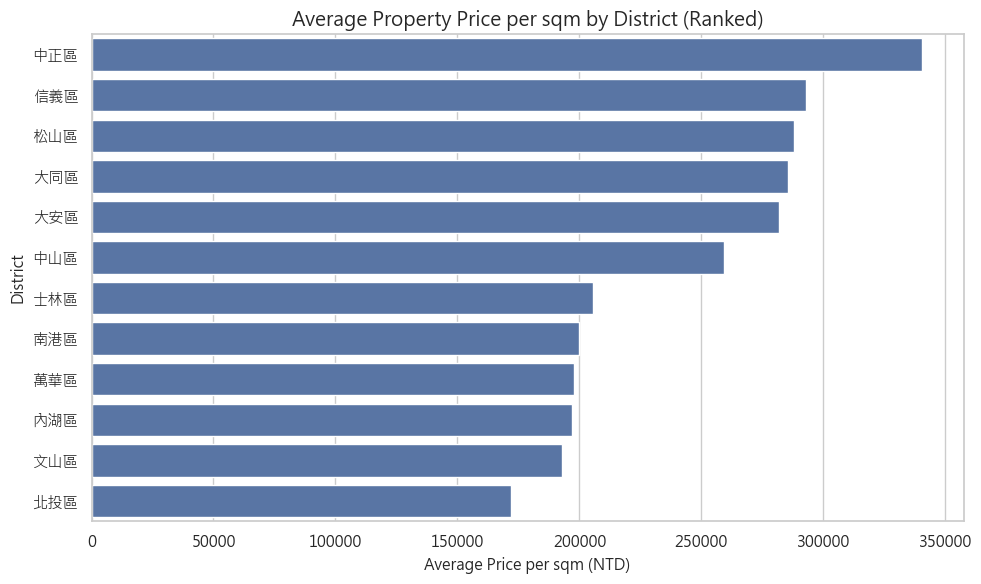

In [28]:
sns.barplot(
    data = district_stats.sort_values(by='avg_price_per_sqm', ascending=False),
    x = 'avg_price_per_sqm',
    y = 'district'
)
plt.title('Average Property Price per sqm by District (Ranked)', fontsize=14)
plt.xlabel('Average Price per sqm (NTD)', fontsize=11)
plt.ylabel('District', fontsize=11)
plt.tight_layout()
plt.show()

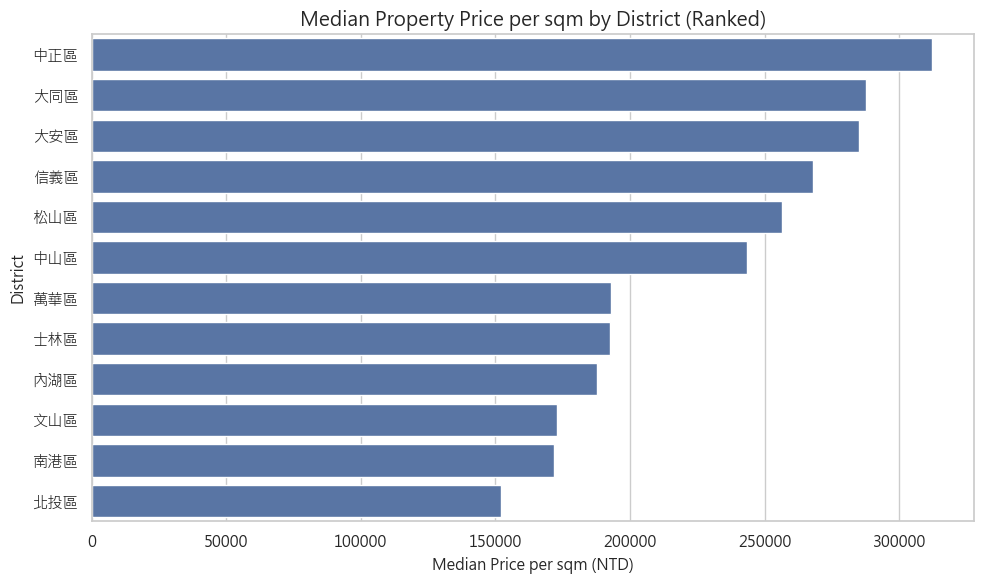

In [29]:
sns.barplot(
    data = district_stats.sort_values(by='median_price_per_sqm', ascending=False),
    x = 'median_price_per_sqm',
    y = 'district'
)
plt.title('Median Property Price per sqm by District (Ranked)', fontsize=14)
plt.xlabel('Median Price per sqm (NTD)', fontsize=11)
plt.ylabel('District', fontsize=11)
plt.tight_layout()
plt.show()

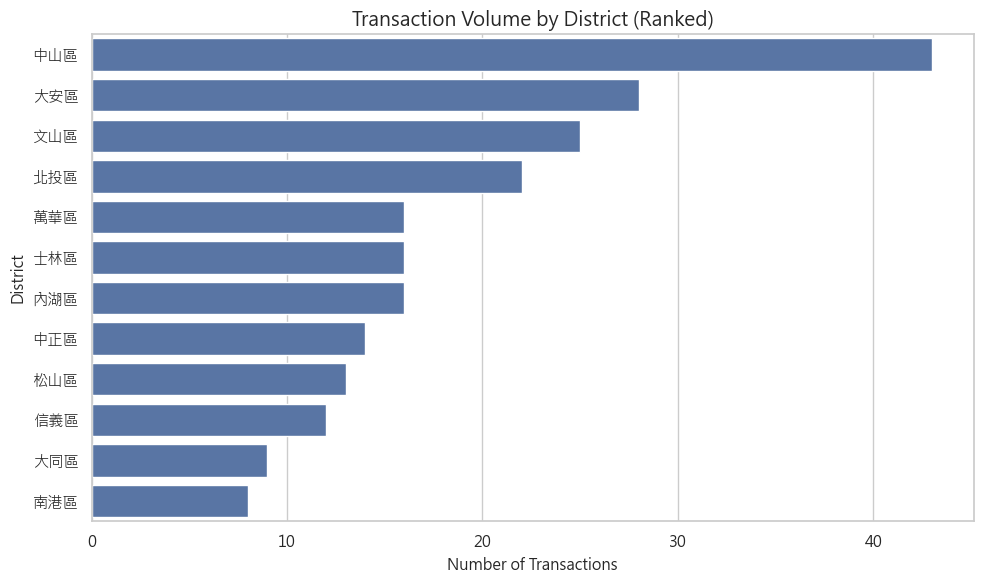

In [30]:
sns.barplot(
    data = district_stats.sort_values(by='transaction_volume', ascending=False),
    x = 'transaction_volume',
    y = 'district'
)
plt.title('Transaction Volume by District (Ranked)', fontsize=14)
plt.xlabel('Number of Transactions', fontsize=11)
plt.ylabel('District', fontsize=11)
plt.tight_layout()
plt.show()

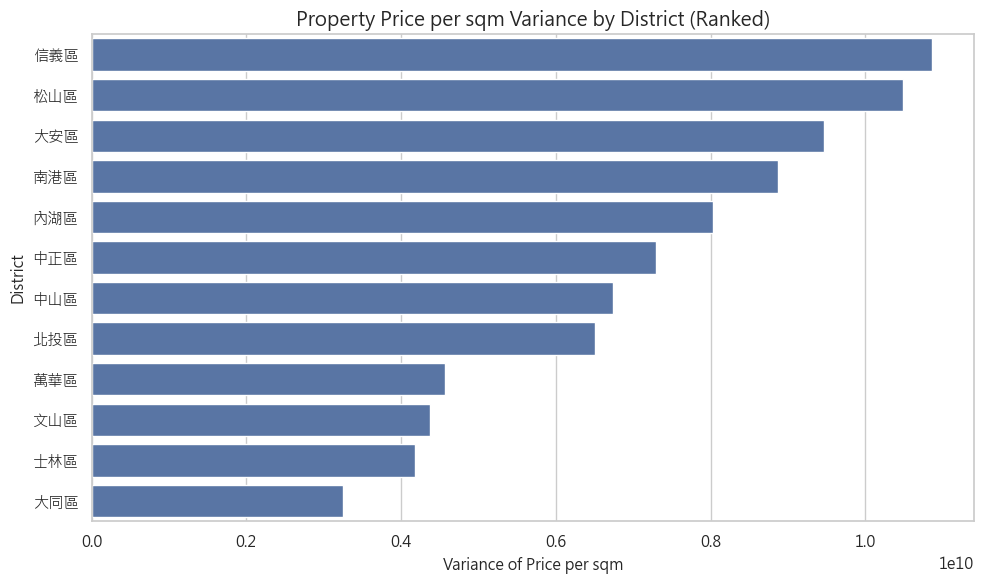

In [31]:
sns.barplot(
    data = district_stats.sort_values(by='var_price_per_sqm', ascending=False),
    x = 'var_price_per_sqm',
    y = 'district'
)
plt.title('Property Price per sqm Variance by District (Ranked)', fontsize=14)
plt.xlabel('Variance of Price per sqm', fontsize=11)
plt.ylabel('District', fontsize=11)
plt.tight_layout()
plt.show()

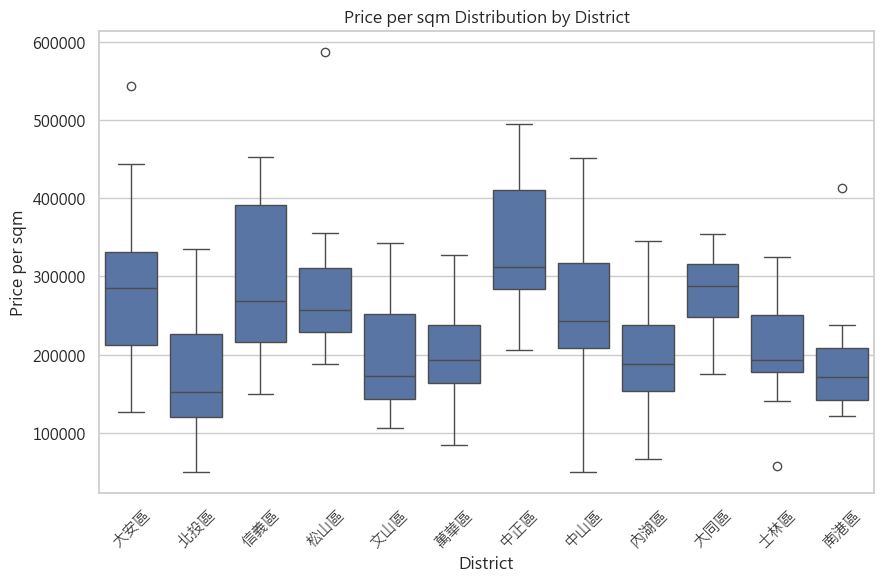

In [32]:
sns.boxplot(
    data=df_mvp,
    x='district',
    y='final_price_per_sqm'
)
plt.title('Price per sqm Distribution by District')
plt.xlabel('District')
plt.ylabel('Price per sqm')
plt.xticks(rotation=45)

plt.show()

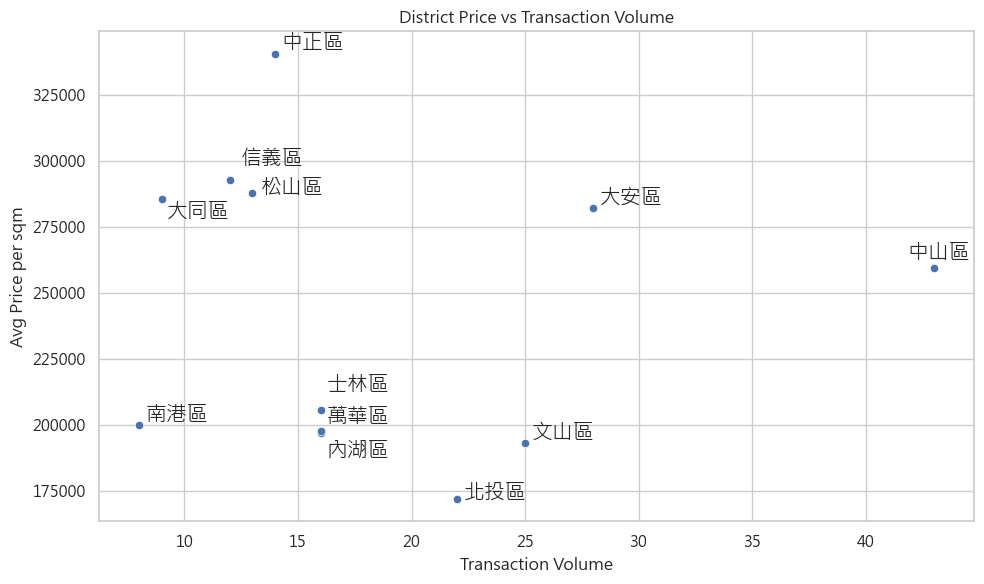

In [33]:
sns.scatterplot(
    data = district_stats,
    x = 'transaction_volume',
    y = 'avg_price_per_sqm'
)

texts = []
for i in range(len(district_stats)):
    x = district_stats['transaction_volume'][i]
    y = district_stats['avg_price_per_sqm'][i]

    texts.append(
        plt.text(x, y, district_stats['district'][i], fontsize=15)
    )

adjust_text(texts)

plt.title('District Price vs Transaction Volume')
plt.xlabel('Transaction Volume')
plt.ylabel('Avg Price per sqm')
plt.tight_layout()
plt.show()

# Day 5 Insight Generation

## Time-Based Analysis

In [34]:
monthly = df_mvp.groupby(df_mvp['date'].dt.to_period('M')).agg(
    avg_price_per_sqm = ('final_price_per_sqm', 'mean'),
    transaction_volume = ('price', 'count')
).reset_index().rename(columns={'date':'year_month'})
monthly['year_month'] = monthly['year_month'].astype(str)
monthly

,year_month,avg_price_per_sqm,transaction_volume
0,2026-01,244399.245902,122
1,2026-02,241839.680556,72
2,2026-03,221716.000000,28


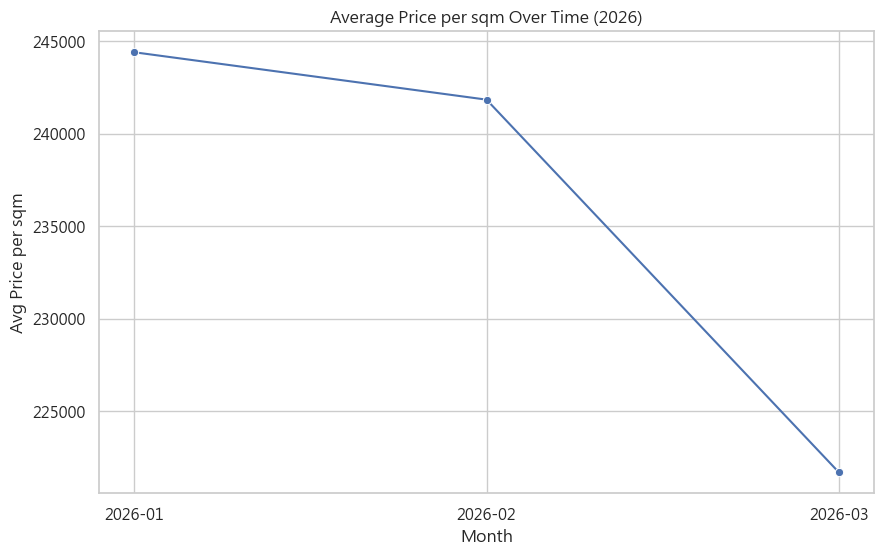

In [35]:
sns.lineplot(
    data=monthly,
    x='year_month',
    y='avg_price_per_sqm',
    marker='o'
)
plt.title('Average Price per sqm Over Time (2026)')
plt.xlabel('Month')
plt.ylabel('Avg Price per sqm')

plt.show()

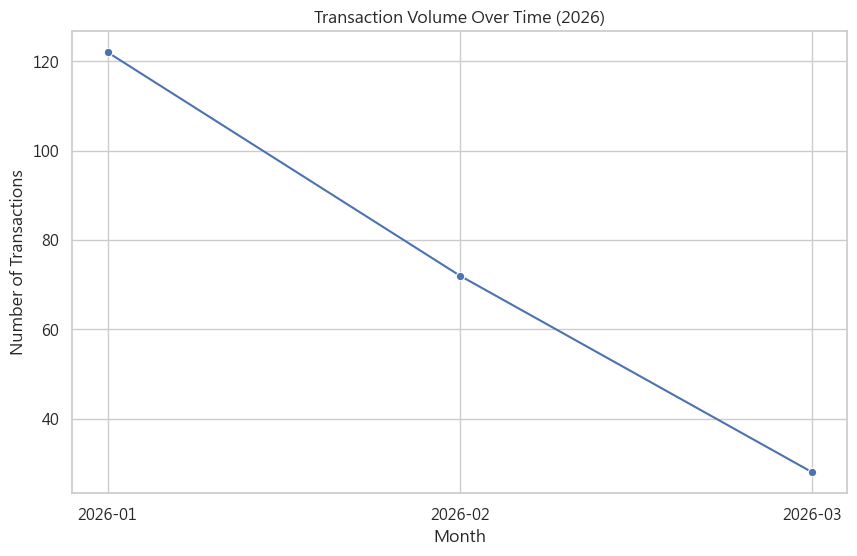

In [36]:
sns.lineplot(
    data=monthly,
    x='year_month',
    y='transaction_volume',
    marker='o'
)
plt.title('Transaction Volume Over Time (2026)')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')

plt.show()

## Document Findings

## 1. District Pricing 
### Observation
- 中正區 recorded the **highest average price per sqm** among all districts.
- 中山區 had the **highest transaction volume** (40+ transactions).
- 大安區 ranked second in transaction volume (~30 transactions).

### Interpretation
- 中山區’s high transaction volume suggests a **high-liquidity market**, where properties are traded more frequently.
- 大安區 shows both **strong demand and active participation**, reinforcing its importance in the market.

### Implication
- There is a clear **separation between “expensive” districts and “active”** districts.
- Investors may view:
    - 中正區 → value retention / premium positioning
    - 中山區 → liquidity / transaction opportunities

## 2. Pricing Variability Across Districts
### Observation
- 信義區 shows the **highest variance** in price per sqm (~1.0e10), with a noticeably wide interquartile range.
- 大同區 has the **lowest variance** (~0.3e10), with a relatively tight distribution.
- Districts such as 中山區 and 大安區 exhibit **long whiskers** in the boxplot, indicating a wide overall price range despite moderate variance.

### Interpretation
- The wide distribution in 信義區 suggests a **diverse mix of property segments**, including high-end properties.
- The tight distribution in 大同區 indicates **more consistent pricing**, likely due to more homogeneous property types.
- The long whiskers observed in 中山區 and 大安區 suggest the presence of **extreme transactions (outliers)**, such as luxury units or unusually low-priced deals.

### Implication
- Different districts exhibit **different types of price dispersion**:
    - 信義區 → variability within the core market (high IQR)
    - 中山區 / 大安區 → broader price range driven by outliers
- This reinforces that:
    - **median price is more reliable than mean**, especially in districts with extreme values
    - investors should consider both:
        - **typical pricing (median)**
        - **risk / spread (variance and range)**

## 3. Time-Based Market Trends (2026 Jan-Mar)
### Observation
- Transaction volume declines from January to March
- Average price per sqm remains relatively stable (~200,000)

### Interpretation
- The decline in volume is likely due to **reporting lag**, where more recent transactions have not yet been fully recorded
- Stable pricing despite lower recorded volume suggests **no immediate downward pressure on prices**

### Implication
- The market appears **stable in the short term**, with no strong upward or downward trend
- However, **recent data should be interpreted cautiously** due to potential incompleteness

# Day 6 Analytical Deep Dive

## Pricing Method Analysis

In [42]:
cols = [
    "price_per_sqm",
    "computed_price_per_sqm",
    "net_price_per_sqm",
    "final_price_per_sqm"
]

df_long = df_mvp[cols].melt(
    var_name="pricing_method",
    value_name="value"
)

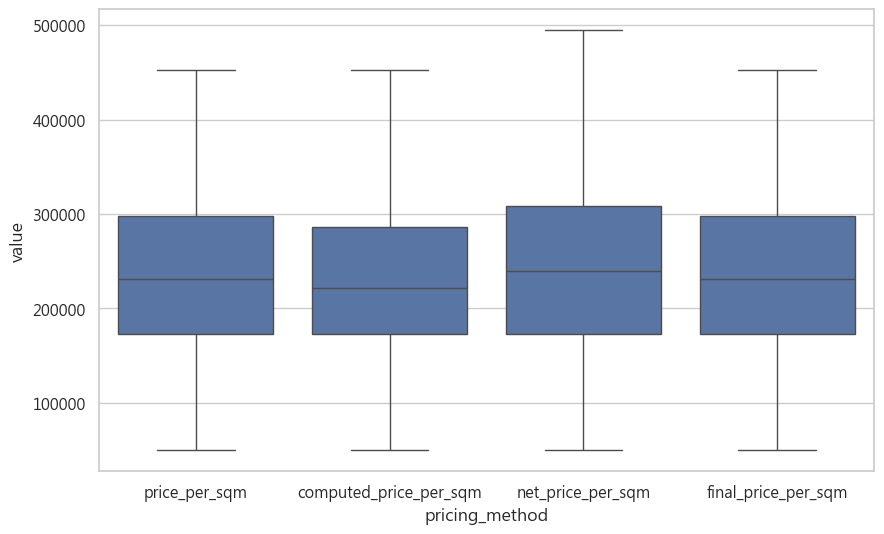

In [44]:
sns.boxplot(
    data=df_long,
    x='pricing_method',
    y='value',
    showfliers=False
)
plt.show()

### Pricing Method Insight

- All pricing methods exhibit highly similar distributions, indicating strong consistency across calculation approaches
- This suggests that parking adjustments and fallback computations do not significantly alter overall pricing patterns
- The final_price_per_sqm metric is therefore considered robust and reliable for analysis
- However, the net-adjusted method shows slightly wider whiskers, implying sensitivity to edge cases such as small net areas
- Overall, the pricing framework is stable, with minor caution required for extreme values in adjusted calculations

In [46]:
print("Mean price_diff:", df_mvp['price_diff'].mean())
print("Mean net_price_diff:", df_mvp['net_price_diff'].mean())

print("Median price_diff:", df_mvp['price_diff'].median())
print("Median net_price_diff:", df_mvp['net_price_diff'].median())

Mean price_diff: 9404.977477477478
Mean net_price_diff: 4352.364864864865
Median price_diff: 0.0
Median net_price_diff: 0.0


### Net adjusted does reduce discrepancies, as shown in decrease in price difference

## District Segmentation

In [54]:
top3 = district_stats.sort_values(by='avg_price_per_sqm', ascending=False).head(3)
bottom3 = district_stats.sort_values(by='avg_price_per_sqm', ascending=True).head(3)

In [55]:
price_gap_ratio = top3['avg_price_per_sqm'].mean() / bottom3['avg_price_per_sqm'].mean()
print(f"Price Gap Ratio: {price_gap_ratio}")

Price Gap Ratio: 1.6402287873660524


In [56]:
price_gap_diff = top3['avg_price_per_sqm'].mean() - bottom3['avg_price_per_sqm'].mean()
print(f"Price Gap Difference: {price_gap_diff}")

Price Gap Difference: 119842.1198948274


In [58]:
top_volume = top3['transaction_share'].sum()
bottom_volume = bottom3['transaction_share'].sum()

print(top_volume)
print(bottom_volume)

17.6
28.400000000000002


In [60]:
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

df_var = df_mvp.groupby('district')['final_price_per_sqm'].agg([
    'mean',
    'median',
    'std',
    'count'
]).reset_index()
df_var['iqr'] = df_mvp.groupby('district')['final_price_per_sqm'].apply(iqr).values

In [62]:
df_var.sort_values(by=['std','iqr'], ascending=False)

,district,mean,median,std,count,iqr
2,信義區,292720.083333,267984.5,104216.060204,12,174484.50
10,松山區,287851.538462,256460.0,102417.624604,13,82199.00
8,大安區,281884.607143,285187.0,97259.912834,28,119197.50
5,南港區,199770.500000,171776.5,94217.529867,8,65879.75
3,內湖區,196822.312500,187677.5,89610.743049,16,84113.00
1,中正區,340513.928571,312135.0,85408.004684,14,126510.00
0,中山區,259360.674419,243590.0,82066.030941,43,108511.00
4,北投區,171829.318182,151972.0,80664.502251,22,105655.50
11,萬華區,197594.750000,193061.0,67605.867859,16,73371.25
9,文山區,192907.560000,172712.0,66177.985968,25,108538.00


High-priced districts such as 信義區, 大安區, 松山區, and 中正區 exhibit significant variability, suggesting a heterogeneous mix of property types and occasional high-value transactions.

大同區 stands out as a high-priced yet low-variance district, indicating a more consistent pricing structure compared to other premium districts.

Districts like 南港區 and 內湖區 show high variability despite mid-level pricing, indicating heterogeneous development and mixed property characteristics.

Mid-priced districts such as 中山區 and 士林區 exhibit moderate variability, reflecting relatively balanced and stable housing markets.

Lower-priced districts like 萬華區 and 北投區 show relatively lower variability, suggesting more standardized and stable housing characteristics.

Some districts have relatively small sample sizes, which may amplify observed variability and limit the reliability of comparisons.

## Data Quality & Reliability Check

In [64]:
df_mvp['pricing_method'].value_counts(normalize=True)

pricing_method
original        0.801802
net_adjusted    0.198198
Name: proportion, dtype: float64

### Pricing Method Distribution

- The dataset consists primarily of `original` and `net_adjusted` pricing methods
- No observations required `fallback_computed`

This indicates that missing or inconsistent `price_per_sqm` values were largely associated with non-housing transactions, which were removed during data filtering.

In [65]:
df_mvp['price_per_sqm'].isna().sum()

np.int64(0)

### Missing & Fallback Analysis

- No rows required fallback computation after filtering
- Missing `price_per_sqm` values were effectively eliminated by restricting the dataset to housing-related transactions

This suggests that the fallback logic is no longer actively used in the current dataset, but remains important as a safeguard for future data ingestion.

In [69]:
df_mvp.groupby('pricing_method')[['price_diff','net_price_diff']].mean()

,price_diff,net_price_diff
pricing_method,,
net_adjusted,47448.863636,0.000000
original,0.870787,5428.230337


The analysis confirms that discrepancies in price per sqm are primarily driven by parking inclusion. 

- Transactions without parking are internally consistent
- Transactions with parking exhibit large discrepancies when using raw values
- Applying net adjustment fully resolves these discrepancies

This validates the use of `final_price_per_sqm` as a standardized and reliable pricing metric.